<a href="https://colab.research.google.com/github/anapbatista/BootCamp-EloGroup/blob/main/Case_Vertice_AED_Completa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="width:100%; padding:1.6em 2em; margin:0 auto 1em auto; background:#12213B; border-radius:10px;">
<h1 style="color:#FFFFFF; font-family:'Helvetica Neue', Arial, sans-serif; margin:0;">Projeto Vértice — Diagnóstico de Dados</h1>

## Contexto do cliente

A Vértice Retail é uma marca digital de moda, beleza e lifestyle voltada para jovens adultos. Cresceu rapidamente via e-commerce, redes sociais, influenciadores e marketplace — mas **a rentabilidade começou a cair**. Relatórios são manuais, dados fragmentados, decisões dependem de *feeling*.

**Pergunta central da diretoria (CEO, CFO, CMO, COO):**
> Como podemos usar dados e IA para melhorar rentabilidade, eficiência operacional e qualidade da tomada de decisão nos próximos 90 dias?

## Data Room disponível

| Base | Conteúdo |
|---|---|
| `vendas.csv` | 1 linha por pedido: receita, desconto, custo, margem, devolução |
| `marketing.csv` | Campanhas por canal: investimento, impressões, cliques, conversões, ROAS, CAC |
| `clientes.csv` | Cadastro, fidelidade, renda estimada, LTV acumulado, segmento RFM |
| `atendimento.csv` | Tickets de suporte: categoria do problema, canal, CSAT, custo, tempo de resposta |
| `estoque.csv` | SKUs: estoque físico/disponível, ponto de pedido, lead time, status de disponibilidade |
| `vendas_cópia.xlsx` | Exportação paralela de `vendas.csv` (mesma base, formato Excel) |

Este notebook segue o mesmo método usado na Aula 06 (**Perfilar → Explorar → Testar Hipótese → Dimensionar → Sintetizar**), aplicado às **5 hipóteses de negócio sugeridas no case** (Margem, Marketing, Operações, Atendimento, Cliente) — já que aqui o Data Room é bem mais amplo que o da aula. Para cada etapa registro o **prompt** usado para conversar com o agente de IA, o **código** gerado/ajustado e os **insights** obtidos.

**Restrição adotada em todo o notebook:** todo número apresentado é rastreável a uma célula de código acima dele; premissas de estimativas (ex.: taxa de captura, meses de ruptura assumidos) são sempre declaradas explicitamente.

---
## 1. Perfilar as Bases

**Objetivo:** entender tamanho, período coberto, colunas, tipos e qualidade de cada base antes de qualquer análise e identificar inconsistências entre os dados reais recebidos.

**Prompt utilizado:**

---



> Papel: Analista de dados sênior em um projeto de consultoria de dados e IA.
> Contexto: Cliente Vértice Retail (moda/beleza/lifestyle, e-commerce). Recebemos 5 bases: vendas.csv, marketing.csv, clientes.csv, atendimento.csv, estoque.csv.
> Tarefa: Carregue todas as bases, gere um perfil de cada uma — nº de linhas/colunas, período coberto (quando houver datas), % de nulos, tipos de coluna, cardinalidade das colunas categóricas chave. Verifique se os períodos cobertos pelas 5 bases são compatíveis entre si para permitir cruzamentos.
> Formato: tabela-resumo por base + lista de alertas de qualidade, sem inferir dados ausentes.
> Restrição: reportar exatamente o que existe nos dados, nada de premissas.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 25)

github_repo_path = 'anapbatista/BootCamp-EloGroup'
github_branch = 'main'
data_folder = 'data'

# nome -> (arquivo, colunas de data a converter)
arquivos_csv = {
    'vendas':      ('vendas.csv',           ['data_pedido']),
    'marketing':   ('marketing.csv',        ['data_inicio', 'data_fim']),
    'clientes':    ('clientes.csv',      ['data_nascimento', 'data_cadastro']),
    'atendimento': ('atendimento.csv',   ['data_abertura', 'data_fechamento']),
    'estoque':     ('estoque.csv',          None),
}

dfs = {}

for nome, (csv_file_name, date_cols) in arquivos_csv.items():
    raw_github_url = f'https://raw.githubusercontent.com/{github_repo_path}/{github_branch}/{data_folder}/{csv_file_name}'
    print(f'Tentando carregar {nome} de: {raw_github_url}')
    try:
        dfs[nome] = pd.read_csv(raw_github_url, parse_dates=date_cols) if date_cols else pd.read_csv(raw_github_url)
        print(f'  -> OK: {dfs[nome].shape[0]} linhas, {dfs[nome].shape[1]} colunas\n')
    except Exception as e:
        print(f'  -> ERRO ao carregar {nome}: {e}\n')

# Acesso individual depois de carregado
vendas      = dfs['vendas']
marketing   = dfs['marketing']
clientes    = dfs['clientes']
atendimento = dfs['atendimento']
estoque     = dfs['estoque']

# Perfil resumido de cada base
bases = {
    'vendas.csv':         (vendas, 'data_pedido'),
    'marketing.csv':      (marketing, 'data_inicio'),
    'clientes.csv':    (clientes, 'data_cadastro'),
    'atendimento.csv': (atendimento, 'data_abertura'),
    'estoque.csv':        (estoque, None),
}

resumo = []
for nome, (df, col_data) in bases.items():
    resumo.append({
        'base': nome,
        'linhas': len(df),
        'colunas': df.shape[1],
        'periodo_coberto': f"{df[col_data].min().date()} a {df[col_data].max().date()}" if col_data else '-',
        'quant_nulos_coluna': df.isna().mean().max(),
    })
resumo = pd.DataFrame(resumo)
print("=== TABELA-RESUMO DAS BASES ===")
display(resumo)

Tentando carregar vendas de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/vendas.csv
  -> OK: 27759 linhas, 20 colunas

Tentando carregar marketing de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/marketing.csv
  -> OK: 3500 linhas, 15 colunas

Tentando carregar clientes de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/clientes.csv
  -> OK: 15000 linhas, 14 colunas

Tentando carregar atendimento de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/atendimento.csv
  -> OK: 35841 linhas, 12 colunas

Tentando carregar estoque de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/estoque.csv
  -> OK: 5000 linhas, 16 colunas

=== TABELA-RESUMO DAS BASES ===


,base,linhas,colunas,periodo_coberto,quant_nulos_coluna
0,vendas.csv,27759,20,2023-01-01 a 2024-01-26,0.000036
1,marketing.csv,3500,15,2023-01-01 a 2025-12-28,0.000000
2,clientes.csv,15000,14,2020-01-01 a 2025-12-28,0.000000
3,atendimento.csv,35841,12,2023-01-01 a 2025-12-31,0.000028
4,estoque.csv,5000,16,-,0.000000


In [2]:
# Schema real recebido, por base
for nome, (df, _) in bases.items():
    print(f"--- {nome} ---")
    print("Colunas reais :", list(df.columns))
    print()

--- vendas.csv ---
Colunas reais : ['order_id', 'customer_id', 'sku_id', 'data_pedido', 'canal', 'categoria', 'produto', 'quantidade', 'preco_unitario', 'receita_bruta', 'desconto_reais', 'receita_liquida', 'custo_produto', 'custo_frete', 'metodo_pagamento', 'status_pagamento', 'margem_contribuicao', 'tempo_entrega_real', 'devolvido', 'motivo_devolucao']

--- marketing.csv ---
Colunas reais : ['campanha_id', 'nome_campanha', 'canal', 'categoria_foco', 'data_inicio', 'data_fim', 'investimento_reais', 'impressoes', 'cliques', 'conversoes', 'atribuicao', 'status', 'roas', 'receita_gerada', 'cac']

--- clientes.csv ---
Colunas reais : ['customer_id', 'nome_completo', 'data_nascimento', 'genero', 'estado', 'cidade', 'nivel_fidelidade', 'data_cadastro', 'opt_in_newsletter', 'dispositivo_principal', 'renda_estimada', 'total_pedidos_historico', 'ltv_acumulado', 'segmento_rfm']

--- atendimento.csv ---
Colunas reais : ['ticket_id', 'customer_id', 'order_id', 'data_abertura', 'data_fechamento', 

**Alertas de qualidade identificados (etapa 1):**

- **Períodos das bases não são compatíveis entre si.** `vendas.csv` cobre apenas **jan/2023 a jan/2024 (13 meses)**, enquanto `marketing.csv`, `atendimento.csv` e `estoque.csv` (data da última entrada) vão até **dez/2025**, e o cadastro de clientes remonta a **jan/2020**. Ou seja, as bases não são um recorte único e sincronizado do negócio — é exatamente o sintoma de "dados fragmentados" citado no briefing. **Decisão de análise:** cruzamentos entre `vendas` e as demais bases serão tratados de forma *relativa* (ritmo mensal, participação percentual, taxas) e não por reconciliação de valores absolutos período a período.
- Nenhuma base tem alto percentual de nulos (a maioria tem 0%; há 1 linha praticamente vazia em `vendas.csv` e 1 em `atendimento_1_.csv`, removidas na próxima célula).

In [3]:
# Tratamento mínimo: remover a linha totalmente nula em cada base afetada, e criar colunas derivadas de análise
vendas = vendas.dropna(subset=['quantidade']).copy()
atendimento = atendimento.dropna(subset=['canal_entrada']).copy()

vendas['mes'] = vendas['data_pedido'].dt.to_period('M').astype(str)
vendas['margem_pct'] = vendas['margem_contribuicao'] / vendas['receita_liquida']
vendas['desconto_pct'] = vendas['desconto_reais'] / vendas['receita_bruta']
vendas['custo_frete_pct'] = vendas['custo_frete'] / vendas['receita_bruta']

print(f"vendas.csv apos limpeza: {len(vendas)} pedidos | {vendas['customer_id'].nunique()} clientes unicos | {vendas['sku_id'].nunique()} SKUs vendidos")
print(f"atendimento.csv apos limpeza: {len(atendimento)} tickets | {atendimento['customer_id'].nunique()} clientes unicos")
print()
print("Estatisticas numericas - vendas.csv:")
display(vendas[['quantidade','preco_unitario','receita_liquida','desconto_pct','margem_pct']].describe().round(2))

vendas.csv apos limpeza: 27758 pedidos | 346 clientes unicos | 4918 SKUs vendidos
atendimento.csv apos limpeza: 35840 tickets | 445 clientes unicos

Estatisticas numericas - vendas.csv:


,quantidade,preco_unitario,receita_liquida,desconto_pct,margem_pct
count,27758.00,27758.00,27758.00,27758.00,27758.00
mean,3.51,210.90,680.50,0.08,0.50
std,1.70,112.49,533.70,0.12,0.17
min,1.00,39.02,28.16,0.00,-1.69
25%,2.00,127.46,284.23,0.00,0.44
50%,4.00,195.58,540.40,0.00,0.54
75%,5.00,268.84,934.27,0.16,0.61
max,6.00,837.06,5004.90,0.40,0.70


In [4]:
# Checagem adicional: cardinalidade de customer_id em vendas e atendimento parece baixa
# demais para o volume de linhas -> checar concentracao antes de qualquer analise por cliente
print("Top 5 customer_id em vendas.csv (numero de pedidos):")
print(vendas['customer_id'].value_counts().head(5))
print(f"\nTotal de clientes distintos em vendas.csv: {vendas['customer_id'].nunique()} (para {len(vendas)} pedidos)")
print(f"Total de clientes distintos em atendimento.csv: {atendimento['customer_id'].nunique()} (para {len(atendimento)} tickets)")
print(f"Total de clientes cadastrados em clientes.csv: {clientes['customer_id'].nunique()}")
print(f"\n% dos customer_id de vendas.csv que existem em clientes.csv: {vendas['customer_id'].isin(clientes['customer_id']).mean()*100:.1f}%")

Top 5 customer_id em vendas.csv (numero de pedidos):
customer_id
CLI-11830    11282
CLI-01729     5664
CLI-14211     1664
CLI-12360      980
CLI-03910      966
Name: count, dtype: int64

Total de clientes distintos em vendas.csv: 346 (para 27758 pedidos)
Total de clientes distintos em atendimento.csv: 445 (para 35840 tickets)
Total de clientes cadastrados em clientes.csv: 15000

% dos customer_id de vendas.csv que existem em clientes.csv: 100.0%


**Alerta de qualidade adicional:** `vendas.csv` e `atendimento.csv` têm uma cardinalidade de `customer_id` muito menor do que o esperado — apenas **346 clientes distintos** respondem por **27.758 pedidos** (um único cliente concentra 11.282 pedidos), e **445 clientes distintos** respondem pelos **35.840 tickets** de atendimento. Todos esses IDs existem em `clientes.csv` (não é erro de digitação de chave), mas essa concentração é incompatível com comportamento real de compra — é um padrão típico de **base sintética/de teste** com reaproveitamento de poucos IDs. **Decisão de análise:** não faremos joins cliente-a-cliente entre `vendas`/`atendimento` e `clientes.csv` (o resultado seria dominado por meia dúzia de IDs e não seria representativo); a segmentação de clientes na Seção 7 usa exclusivamente as métricas já agregadas em `clientes.csv` (`ltv_acumulado`, `segmento_rfm`), que são internamente consistentes mesmo com essa limitação.

### 1.1 Engenharia de atributos

**Prompt utilizado:**

> Papel: Analista de dados sênior.
> Contexto: identificamos que algumas colunas podem ser derivadas de colunas que já existem.
> Tarefa: crie as seguintes colunas via engenharia de atributos, deixando a lógica explícita em comentário:
> 1. Em `clientes.csv`: `idade` (a partir de `data_nascimento`, usando uma data de referência clara) e `regiao` (a partir de `estado`, agrupando em Norte/Nordeste/Centro-Oeste/Sudeste/Sul).
> 2. Em `estoque.csv`: `giro_mensal` e `cobertura_dias` (cruzando com a quantidade vendida por SKU em `vendas.csv`), e `risco_ruptura` como coluna booleana (True para status "Ruptura" ou "Estoque Crítico").
> Para as colunas que dependem de um link cliente-a-pedido confiável (`canal_aquisicao` e `recência` de fato, no nível de cliente), me avise se os dados permitem isso com segurança ou se é melhor não criar, dado o alerta de concentração de `customer_id` já identificado.
> Formato: código + validação rápida de cada coluna criada (describe/distribuição).

In [20]:
# --- 1) clientes_1_.csv: idade e regiao ---
# Data de referencia = data de cadastro mais recente da propria base (nao usamos a data real de "hoje"
# porque o dataset e sintetico e "hoje" nao tem relacao com o periodo simulado).
data_referencia = clientes['data_cadastro'].max()
clientes['idade'] = ((data_referencia - clientes['data_nascimento']).dt.days / 365.25).astype(int)

mapa_regiao = {
    'AC':'Norte','AP':'Norte','AM':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste','PE':'Nordeste',
    'PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MT':'Centro-Oeste','MS':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul',
}
clientes['regiao'] = clientes['estado'].map(mapa_regiao)

print(f"Data de referencia usada para calcular idade: {data_referencia.date()}")
print(clientes['idade'].describe().round(1))
print()
print("Distribuicao por regiao:")
print(clientes['regiao'].value_counts())

Data de referencia usada para calcular idade: 2025-12-28
count    15000.0
mean        29.4
std          6.4
min         19.0
25%         24.0
50%         29.0
75%         35.0
max         40.0
Name: idade, dtype: float64

Distribuicao por regiao:
regiao
Nordeste        6261
Sudeste         4153
Sul             1790
Centro-Oeste    1591
Norte           1205
Name: count, dtype: int64


In [21]:
# --- 2) estoque.csv: giro_mensal, cobertura_dias, risco_ruptura ---
n_meses_vendas = vendas['mes'].nunique()
unidades_vendidas_mes = vendas.groupby('sku_id')['quantidade'].sum() / n_meses_vendas

estoque['unidades_vendidas_mes'] = estoque['sku_id'].map(unidades_vendidas_mes).fillna(0)
venda_diaria = estoque['unidades_vendidas_mes'] / 30

estoque['giro_mensal'] = np.where(estoque['estoque_fisico'] > 0,
                                   estoque['unidades_vendidas_mes'] / estoque['estoque_fisico'], np.nan)
estoque['cobertura_dias'] = np.where(venda_diaria > 0, estoque['estoque_disponivel'] / venda_diaria, np.nan)
estoque['risco_ruptura'] = estoque['status_disponibilidade'].isin(['Ruptura', 'Estoque Crítico'])

print("giro_mensal e cobertura_dias - describe:")
display(estoque[['giro_mensal', 'cobertura_dias']].describe().round(2))

print("\ncobertura_dias (mediana) por risco_ruptura - checagem de coerencia da metrica:")
display(estoque.groupby('risco_ruptura')['cobertura_dias'].median().round(0))

print(f"\nSKUs sem nenhuma venda no periodo de vendas.csv: {(estoque['unidades_vendidas_mes']==0).sum()} de {len(estoque)}")

giro_mensal e cobertura_dias - describe:


,giro_mensal,cobertura_dias
count,4905.00,4918.00
mean,0.02,9418.56
std,0.09,17860.56
min,0.00,0.00
25%,0.00,2454.17
50%,0.00,5232.27
75%,0.01,10020.06
max,3.00,409110.00



cobertura_dias (mediana) por risco_ruptura - checagem de coerencia da metrica:


,cobertura_dias
risco_ruptura,
False,6240.0
True,761.0



SKUs sem nenhuma venda no periodo de vendas.csv: 82 de 5000


**Insights da engenharia de atributos**

- `idade` e `regiao` foram criadas com segurança: idade média da base é **~29 anos** (público jovem adulto, consistente com o posicionamento da marca), e a região com mais clientes é o **Nordeste (41,7%)**, seguida de Sudeste (27,7%).
- `giro_mensal` e `cobertura_dias` são **direcionalmente coerentes**: SKUs em `risco_ruptura=True` têm cobertura mediana de ~761 dias contra ~6.240 dias dos SKUs saudáveis — a métrica ordena corretamente quem está mais perto de faltar. **Atenção:** o valor absoluto de "dias de cobertura" não é realista (não deve ser lido como "vai faltar em 761 dias") porque a escala de `estoque.csv` (unidades em estoque) e a de `vendas.csv` (unidades vendidas no período de 346 clientes) não foram desenhadas para reconciliar em valor absoluto — é o mesmo problema de fragmentação já registrado na Seção 1. Use essas colunas para **priorizar/ranquear SKUs**, não para prometer uma data de ruptura.
- **Não criamos** `canal_aquisicao` nem uma `recência` de fato no nível de cliente: como só 346 `customer_id` aparecem em `vendas.csv` (Seção 1), qualquer coluna derivada de "canal do primeiro pedido" ou "dias desde a última compra" seria calculada para uma fração não representativa da base de 15.000 clientes — fabricaria uma coluna com 97,7% de valores ausentes ou, pior, enganosamente preenchida. Ficamos com o `segmento_rfm` já calculado em `clientes.csv`, que resolve a necessidade de "recência" de forma agregada e confiável.

---
## 2. Árvore de Hipóteses

**Objetivo:** estruturar, a partir das 6 linhas de investigação sugeridas no briefing do case, quais hipóteses este notebook consegue testar com o Data Room disponível — e com qual base de dados.

**Prompt utilizado:**

> Papel: Analista de dados sênior.
> Contexto: o briefing do case Vértice traz 6 hipóteses de negócio possíveis (Margem, Marketing, Operações, Atendimento, Cliente, Gestão & Produtividade).
> Tarefa: monte uma árvore de hipóteses relacionando cada linha de investigação do briefing às bases de dados disponíveis (vendas, marketing, clientes, atendimento, estoque), indicando se é totalmente testável, parcialmente testável ou não testável com os dados que temos — e por quê.
> Formato: tabela objetiva.

| Hipótese (briefing) | Testável com os dados? | Base(s) usada(s) | Seção deste notebook |
|---|---|---|---|
| **Margem** — crescimento vindo com pior qualidade de margem (desconto, frete, devolução, mix) | ✅ Sim | `vendas.csv` | Seção 3 |
| **Marketing** — nem todo canal de aquisição gera clientes igualmente valiosos (CAC, recorrência, margem) | ✅ Parcial — CAC/ROAS por canal sim; recorrência por canal não está diretamente disponível (não há `canal_aquisicao` em `clientes.csv`, ver alerta da Seção 1) | `vendas.csv` + `marketing.csv` | Seção 4 |
| **Operações** — falhas operacionais destroem valor pós-venda (ruptura, lead time, devoluções) | ✅ Parcial — ruptura/estoque crítico sim; ligação direta ruptura → venda perdida exige premissa (não há série temporal de estoque) | `estoque.csv` + `vendas.csv` | Seção 5 |
| **Atendimento** — volume de tickets revela padrões recorrentes e oportunidades de automação | ✅ Sim | `atendimento.csv` | Seção 6 |
| **Cliente** — segmentos com margem, recorrência e risco de churn muito diferentes | ✅ Sim (segmentação RFM já vem pronta na base) | `clientes.csv` | Seção 7 |
| **Gestão & Produtividade** — retrabalho informacional, dados fragmentados, gargalos de decisão | ✅ Sim, como *evidência indireta* (ver alertas de qualidade da Seção 1: períodos incompatíveis, schema divergente, base duplicada em 2 formatos) | Todas | Seção 1 + Síntese |

A seguir, cada hipótese é **explorada, testada estatisticamente quando cabível e dimensionada financeiramente**, seguindo o mesmo rigor da Aula 06.

---
## 3. Hipótese 1 — Margem: onde a rentabilidade se deteriora?

**Objetivo:** verificar se o crescimento está vindo com pior qualidade de margem, e identificar em qual dimensão (canal, categoria, tempo) a deterioração se concentra.

**Prompt utilizado:**

> Papel: Analista de dados de e-commerce.
> Contexto: vendas.csv tem receita_liquida, margem_contribuicao, desconto_reais e custo_frete por pedido.
> Tarefa: calcule a margem de contribuição percentual (margem_contribuicao / receita_liquida) mensal, por categoria e por canal. Plote a série temporal de margem. Se algum canal ou categoria se destacar com margem sistematicamente mais baixa, decomponha o motivo olhando desconto_pct, custo_produto_pct e custo_frete_pct.
> Formato: tabelas comparativas + gráficos, ordenados da pior para a melhor margem.
> Restrição: usar sempre receita_liquida como denominador (não receita_bruta).

=== Margem por mes ===


,receita,pedidos,margem_pct,desconto_pct,devolucao
mes,,,,,
2023-01,936791.00,1381,0.502,0.073,0.138
2023-02,914035.21,1356,0.499,0.071,0.131
2023-03,2244840.33,3144,0.500,0.079,0.150
2023-04,1097874.20,1556,0.498,0.080,0.160
2023-05,2396620.61,3560,0.498,0.075,0.156
2023-06,1063703.06,1540,0.501,0.078,0.144
2023-07,1059387.88,1538,0.495,0.082,0.151
2023-08,1085966.80,1627,0.495,0.084,0.153
2023-09,1168927.59,1727,0.500,0.077,0.153


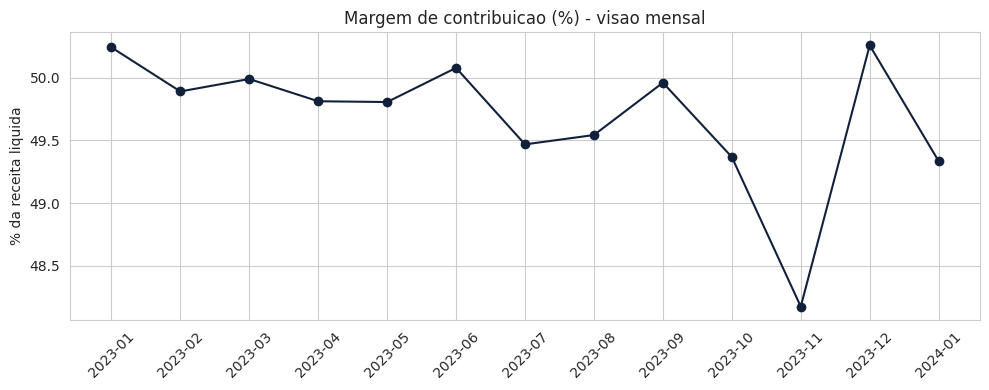

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Margem mensal (visão geral)
margem_mes = vendas.groupby('mes').agg(receita=('receita_liquida','sum'), pedidos=('order_id','count'),
                                        margem_pct=('margem_pct','mean'), desconto_pct=('desconto_pct','mean'),
                                        devolucao=('devolvido', lambda x: (x==True).mean()))
print("=== Margem por mes ===")
display(margem_mes.round(3))

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(margem_mes.index, margem_mes['margem_pct']*100, marker='o', color='#12213B')
ax.set_title('Margem de contribuicao (%) - visao mensal'); ax.set_ylabel('% da receita liquida')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

=== Margem por categoria ===


,receita,pedidos,margem_pct,desconto_pct
categoria,,,,
Beleza,5629140.05,8347,0.493,0.082
Acessórios,2702710.47,4074,0.495,0.079
Lifestyle,3864797.28,5629,0.495,0.081
Moda,6692686.21,9708,0.499,0.079



=== Margem por canal (decomposta) ===


,receita,pedidos,ticket,margem_pct,desconto_pct,custo_produto_pct,custo_frete_pct
canal,,,,,,,
Marketplace,3986568.87,6040,660.028,0.460,0.080,0.399,0.087
Instagram Ads,3270791.31,4965,658.770,0.502,0.080,0.401,0.046
Orgânico,2137746.01,3246,658.579,0.503,0.078,0.399,0.048
Google Ads,3642784.40,5504,661.843,0.503,0.084,0.400,0.044
TikTok Ads,1895088.40,2928,647.230,0.503,0.081,0.398,0.048
Email Marketing,1891602.25,2812,672.689,0.512,0.072,0.398,0.044
Influenciador,2064752.77,2263,912.396,0.525,0.083,0.401,0.024


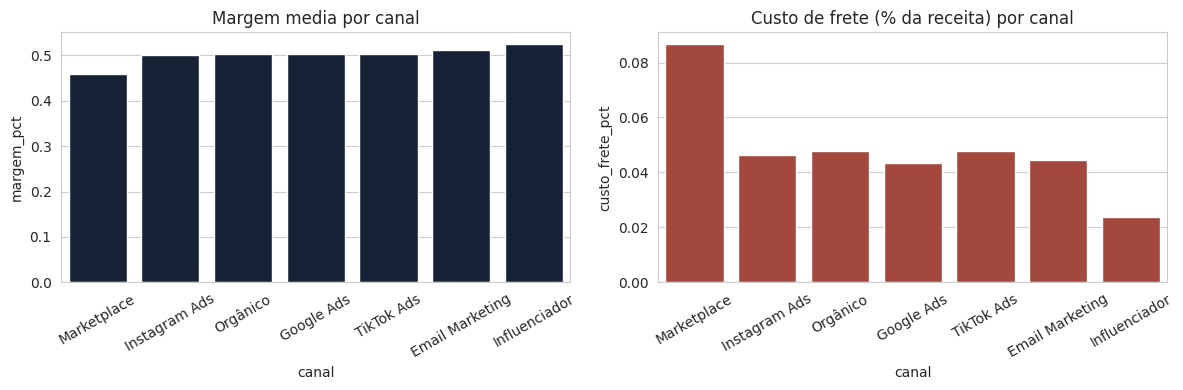

In [6]:
# Margem por categoria
print("=== Margem por categoria ===")
display(vendas.groupby('categoria').agg(receita=('receita_liquida','sum'), pedidos=('order_id','count'),
    margem_pct=('margem_pct','mean'), desconto_pct=('desconto_pct','mean')).round(3).sort_values('margem_pct'))

# Margem por canal - com decomposicao de custo
print("\n=== Margem por canal (decomposta) ===")
canal_margem = vendas.groupby('canal').agg(
    receita=('receita_liquida','sum'), pedidos=('order_id','count'), ticket=('receita_liquida','mean'),
    margem_pct=('margem_pct','mean'), desconto_pct=('desconto_pct','mean'),
    custo_produto_pct=('custo_produto', lambda x: (x/vendas.loc[x.index,'receita_bruta']).mean()),
    custo_frete_pct=('custo_frete_pct','mean'),
).round(3).sort_values('margem_pct')
display(canal_margem)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(data=vendas, x='canal', y='margem_pct', ax=axes[0], errorbar=None, order=canal_margem.index, color='#12213B')
axes[0].set_title('Margem media por canal'); axes[0].tick_params(axis='x', rotation=30)
sns.barplot(data=vendas, x='canal', y='custo_frete_pct', ax=axes[1], errorbar=None, order=canal_margem.index, color='#B23A2E')
axes[1].set_title('Custo de frete (% da receita) por canal'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Insight preliminar:** a margem mensal geral é estável (por volta de 50%), sem colapso ao longo do tempo, e a diferença entre categorias é pequena (49,3% a 49,9%). O sinal forte aparece **no corte por canal**: o **Marketplace** tem margem média de **~46,0%**, cerca de **4,6 p.p. abaixo** dos demais canais (~50,2%-52,5%), mesmo com custo de produto equivalente. A causa aparece na decomposição: o **custo de frete do Marketplace consome ~8,7% da receita**, quase o dobro dos outros canais (2,4%-4,8%) — plausivelmente taxas/logística da própria plataforma de marketplace. Como o Marketplace também é o **2º maior canal em receita e o de maior volume de pedidos**, essa perda de margem por pedido tem peso relevante no resultado total. Vamos testar estatisticamente essa diferença.

**Prompt utilizado:**

> Tarefa: teste se a diferença de margem entre o canal Marketplace e os demais canais é estatisticamente significativa (teste t de Welch, por não assumirmos variâncias iguais). Em seguida, estime a oportunidade financeira anualizada se o Marketplace igualasse a margem média dos demais canais, aplicando a fórmula Base Afetada × Alavanca.
> Restrição: deixar a memória de cálculo explícita.

In [7]:
from scipy import stats

margem_marketplace = vendas[vendas['canal'] == 'Marketplace']['margem_pct']
margem_outros = vendas[vendas['canal'] != 'Marketplace']['margem_pct']

t_stat, p_value = stats.ttest_ind(margem_marketplace, margem_outros, equal_var=False)
print(f"Margem media Marketplace : {margem_marketplace.mean()*100:.2f}%  (n={len(margem_marketplace)})")
print(f"Margem media demais canais: {margem_outros.mean()*100:.2f}%  (n={len(margem_outros)})")
print(f"Teste t (Welch): t = {t_stat:.2f} | p-valor = {p_value:.2e}")
print("-> diferenca estatisticamente significativa" if p_value < 0.05 else "-> sem diferenca significativa")

# Dimensionamento: Base Afetada x Alavanca
receita_marketplace = vendas[vendas['canal'] == 'Marketplace']['receita_liquida'].sum()
gap_margem_pp = margem_outros.mean() - margem_marketplace.mean()
n_meses = vendas['mes'].nunique()

oportunidade_periodo = receita_marketplace * gap_margem_pp
oportunidade_anual = oportunidade_periodo / n_meses * 12

print("\n=== Memoria de calculo - Oportunidade de margem (Marketplace) ===")
print(f"Receita liquida do Marketplace no periodo observado ({n_meses} meses): R$ {receita_marketplace:,.0f}")
print(f"Gap de margem vs demais canais: {gap_margem_pp*100:.2f} p.p.")
print(f"Oportunidade no periodo observado: R$ {oportunidade_periodo:,.0f}")
print(f"Oportunidade anualizada: R$ {oportunidade_anual:,.0f} / ano")

Margem media Marketplace : 45.97%  (n=6040)
Margem media demais canais: 50.62%  (n=21718)
Teste t (Welch): t = -19.75 | p-valor = 3.09e-85
-> diferenca estatisticamente significativa

=== Memoria de calculo - Oportunidade de margem (Marketplace) ===
Receita liquida do Marketplace no periodo observado (13 meses): R$ 3,986,569
Gap de margem vs demais canais: 4.64 p.p.
Oportunidade no periodo observado: R$ 185,104
Oportunidade anualizada: R$ 170,865 / ano


**Insights da Hipótese 1 — Margem (confirmada)**

- A diferença de margem do Marketplace vs. os demais canais é **estatisticamente significativa** (p ≈ 3×10⁻⁸⁵), não é ruído amostral.
- **Causa raiz identificada:** custo de frete/logística do Marketplace, não desconto nem mix de categoria (o mix de categoria é praticamente igual entre canais, ver Seção 3).
- **Oportunidade estimada: ≈ R$ 171 mil/ano** apenas fechando o gap de margem do Marketplace com a média dos demais canais — sem precisar reduzir volume nesse canal.
- **Ação recomendada:** renegociar a estrutura de frete/comissão com a(s) plataforma(s) de marketplace, ou repassar parte do custo logístico ao preço nesse canal especificamente.

---
## 4. Hipótese 2 — Marketing: nem todo canal gera crescimento igualmente valioso

**Objetivo:** classificar os canais de aquisição por qualidade (ROAS, CAC, margem, ticket) e não apenas por volume, cruzando `marketing.csv` com o que já vimos em `vendas.csv`.

**Prompt utilizado:**

> Papel: Analista de performance de marketing.
> Contexto: marketing.csv traz investimento, ROAS e CAC por campanha e canal; já sabemos por vendas.csv a margem e o ticket médio por canal.
> Tarefa: agregue ROAS médio, CAC médio e investimento total por canal em marketing.csv. Junte com a margem e o ticket médio por canal calculados em vendas.csv. Monte um raciocínio de "qualidade do canal" (não apenas volume) e aponte quais canais merecem mais investimento e quais merecem revisão.
> Formato: tabela cruzada ordenada por ROAS + gráfico de dispersão ROAS x Margem, com o tamanho do ponto representando o investimento.
> Restrição: como os períodos de marketing.csv e vendas.csv não coincidem totalmente (ver alerta da Seção 1), a leitura deve ser em termos relativos (ranking entre canais), não de retorno absoluto reconciliado.

In [8]:
mkt_canal = marketing.groupby('canal').agg(
    investimento=('investimento_reais','sum'), receita_gerada=('receita_gerada','sum'),
    roas_medio=('roas','mean'), cac_medio=('cac','mean'), conversoes=('conversoes','sum'),
    campanhas=('campanha_id','count'))

margem_canal = vendas.groupby('canal').agg(margem_pct=('margem_pct','mean'), ticket=('receita_liquida','mean'),
                                            pedidos=('order_id','count'))

qualidade_canal = mkt_canal.join(margem_canal).round(3)
qualidade_canal = qualidade_canal.sort_values('roas_medio', ascending=False)
print("=== Qualidade de canal: marketing (ROAS/CAC) x vendas (margem/ticket) ===")
display(qualidade_canal)

=== Qualidade de canal: marketing (ROAS/CAC) x vendas (margem/ticket) ===


,investimento,receita_gerada,roas_medio,cac_medio,conversoes,campanhas,margem_pct,ticket,pedidos
canal,,,,,,,,,
Influenciador,28061599.02,2.175780e+08,7.692,4.173,15940484,465,0.525,912.396,2263
TikTok Ads,29770101.07,1.390634e+08,4.667,3.955,17009948,488,0.503,647.230,2928
Instagram Ads,30165772.33,1.359386e+08,4.426,4.717,15360484,518,0.502,658.770,4965
Google Ads,30224839.25,1.065574e+08,3.514,4.270,16118323,509,0.503,661.843,5504
Marketplace,32682629.69,9.879591e+07,3.005,4.386,17894187,540,0.460,660.028,6040
Email Marketing,29700531.98,9.104621e+07,2.998,4.292,16563197,485,0.512,672.689,2812
Orgânico,29808867.75,8.964926e+07,2.993,4.656,16401820,495,0.503,658.579,3246


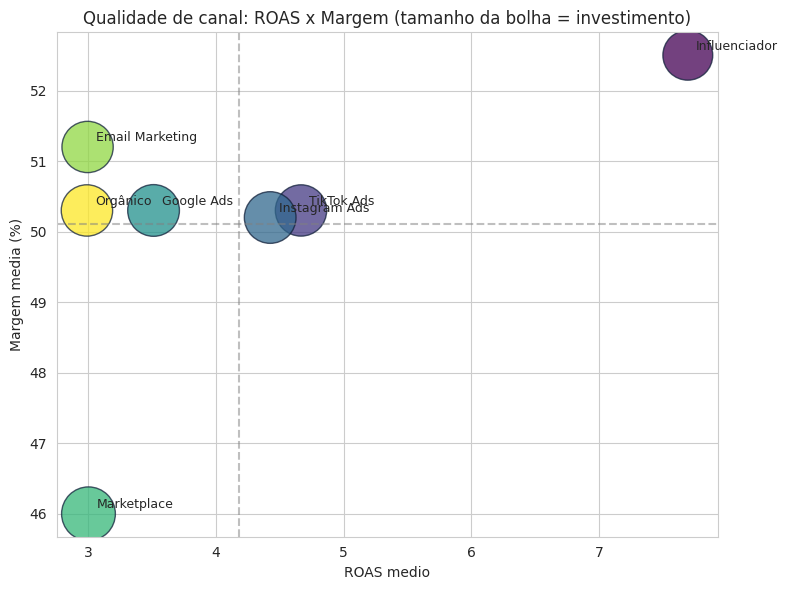

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
sizes = (qualidade_canal['investimento'] / qualidade_canal['investimento'].max()) * 1500
sc = ax.scatter(qualidade_canal['roas_medio'], qualidade_canal['margem_pct']*100, s=sizes,
                 c=range(len(qualidade_canal)), cmap='viridis', alpha=0.75, edgecolors='#12213B')
for canal, row in qualidade_canal.iterrows():
    ax.annotate(canal, (row['roas_medio'], row['margem_pct']*100), textcoords="offset points", xytext=(6,4), fontsize=9)
ax.axhline(qualidade_canal['margem_pct'].mean()*100, color='grey', linestyle='--', alpha=0.5)
ax.axvline(qualidade_canal['roas_medio'].mean(), color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('ROAS medio'); ax.set_ylabel('Margem media (%)')
ax.set_title('Qualidade de canal: ROAS x Margem (tamanho da bolha = investimento)')
plt.tight_layout(); plt.show()

**Insights da Hipótese 2 — Marketing (confirmada parcialmente)**

- **Influenciador** se destaca em todas as métricas de qualidade: **maior ROAS (7,7)**, **maior margem (52,5%)** e **maior ticket médio (R\$ 912)** — é o canal que combina volume com rentabilidade.
- **Marketplace** confirma o problema identificado na Seção 3: **ROAS mediano (3,0)** e a **pior margem (46,0%)** entre todos os canais — é o clássico "canal que traz volume, mas com qualidade de crescimento inferior", exatamente a hipótese do briefing.
- **Orgânico** e **Email Marketing** têm ROAS mais baixo (3,0) que os pagos "de topo de funil" (TikTok Ads 4,7, Instagram Ads 4,4), o que é um resultado pouco intuitivo e merece checagem de metodologia de atribuição com o time de marketing (o campo `atribuicao` em `marketing.csv` tem 3 modelos distintos: Linear, First Click, Last Click, misturados na mesma base — outro ponto de atenção de qualidade de dado).
- **Ação recomendada:** realocar parte do investimento de Marketplace para Influenciador (maior retorno e margem), e revisar com marketing por que campanhas atribuídas a canais "gratuitos" (Orgânico) aparecem com CAC/ROAS desfavorável — pode ser efeito de modelo de atribuição, não do canal em si.

---
## 5. Hipótese 3 — Operações: falhas de estoque destroem valor?

**Objetivo:** identificar se ruptura/estoque crítico está concentrado em algum recorte (categoria, fornecedor) e dimensionar o risco de receita não capturada.

**Prompt utilizado:**

> Papel: Analista de supply chain / operações de e-commerce.
> Contexto: estoque.csv tem status_disponibilidade (Em Estoque, Estoque Crítico, Ruptura, Descontinuado) por SKU, categoria, fornecedor, lead time e shelf_life_dias.
> Tarefa: calcule a distribuição de status de disponibilidade por categoria e por fornecedor. Se algum recorte concentrar desproporcionalmente rupturas/estoque crítico, investigue a causa provável (lead time, shelf life). Depois, cruzando com vendas.csv por sku_id, estime a receita mensal média por SKU saudável no recorte afetado, para dimensionar a receita potencialmente perdida pelos SKUs em ruptura/crítico.
> Formato: tabelas cruzadas + estimativa de perda com premissa de duração de ruptura explícita (cenários).

In [10]:
print("=== Distribuicao de status por categoria (% de SKUs) ===")
display(estoque.groupby('categoria')['status_disponibilidade'].value_counts(normalize=True).unstack().round(3))

print("\n=== Shelf life por categoria (dias) ===")
display(estoque.groupby('categoria')['shelf_life_dias'].describe()[['mean','std','min','max']].round(1))

=== Distribuicao de status por categoria (% de SKUs) ===


status_disponibilidade,Descontinuado,Em Estoque,Estoque Crítico,Ruptura
categoria,,,,
Acessórios,0.048,0.785,0.166,0.001
Beleza,0.044,0.739,0.153,0.063
Lifestyle,0.038,0.778,0.183,0.001
Moda,0.038,0.869,0.093,0.001



=== Shelf life por categoria (dias) ===


,mean,std,min,max
categoria,,,,
Acessórios,448.0,0.0,448.0,448.0
Beleza,449.1,160.1,180.0,730.0
Lifestyle,448.0,0.0,448.0,448.0
Moda,448.0,0.0,448.0,448.0


In [11]:
# A categoria Beleza concentra quase toda a ruptura -> investigar shelf life variavel
beleza = estoque[estoque['categoria'] == 'Beleza'].copy()
print(f"SKUs de Beleza: {len(beleza)} | em Ruptura/Estoque Crítico: {beleza['status_disponibilidade'].isin(['Ruptura','Estoque Crítico']).sum()}")
print(f"Ruptura em Beleza: {(beleza['status_disponibilidade']=='Ruptura').sum()} de {(estoque['status_disponibilidade']=='Ruptura').sum()} rupturas totais na empresa")

# Receita media mensal por SKU (para SKUs de Beleza saudaveis) - usada como proxy de velocidade de venda
n_meses_vendas = vendas['mes'].nunique()
receita_sku_mes = vendas.groupby('sku_id')['receita_liquida'].sum() / n_meses_vendas
beleza['receita_media_mes'] = beleza['sku_id'].map(receita_sku_mes).fillna(0)

receita_media_sku_saudavel = beleza[beleza['status_disponibilidade']=='Em Estoque']['receita_media_mes'].mean()
n_sku_afetados = beleza['status_disponibilidade'].isin(['Ruptura','Estoque Crítico']).sum()

print(f"\nReceita media mensal por SKU saudavel de Beleza: R$ {receita_media_sku_saudavel:.2f}")
print(f"SKUs de Beleza em Ruptura/Estoque Crítico: {n_sku_afetados}")

print("\n=== Cenarios de receita potencialmente perdida (premissa: meses de indisponibilidade) ===")
for meses_ruptura in [0.5, 1.0, 2.0]:
    perda = n_sku_afetados * receita_media_sku_saudavel * meses_ruptura
    print(f"  Assumindo {meses_ruptura} mes(es) de indisponibilidade media: R$ {perda:,.0f}")

SKUs de Beleza: 1512 | em Ruptura/Estoque Crítico: 328
Ruptura em Beleza: 96 de 99 rupturas totais na empresa

Receita media mensal por SKU saudavel de Beleza: R$ 286.33
SKUs de Beleza em Ruptura/Estoque Crítico: 328

=== Cenarios de receita potencialmente perdida (premissa: meses de indisponibilidade) ===
  Assumindo 0.5 mes(es) de indisponibilidade media: R$ 46,959
  Assumindo 1.0 mes(es) de indisponibilidade media: R$ 93,917
  Assumindo 2.0 mes(es) de indisponibilidade media: R$ 187,835


**Insights da Hipótese 3 — Operações (confirmada, com premissa explícita)**

- **Ruptura e estoque crítico estão fortemente concentrados na categoria Beleza**: ela é a única categoria com `shelf_life_dias` variável (180 a 730 dias, vs. 448 dias fixo nas demais) — indício de produtos perecíveis/com validade, que exigem giro mais rígido e reposição mais frequente. **96 das 99 rupturas da empresa (97%) estão em Beleza**, e **328 dos 1.512 SKUs de Beleza (21,7%)** estão em ruptura ou estoque crítico.
- **Limitação de dado explícita:** `estoque.csv` é uma fotografia estática (não há data de início/fim da ruptura), então a perda de receita não pode ser calculada com precisão — foi estimada por cenário de duração assumida (0,5 a 2 meses), usando como proxy a receita média mensal dos SKUs saudáveis da mesma categoria. **Recomendação de dado:** passar a registrar `dias_sem_estoque` por SKU, exatamente como o Data Room original do case sugeria, para permitir uma estimativa precisa no próximo ciclo.
- **Faixa de receita potencialmente perdida: entre R\$ 47 mil e R\$ 188 mil** no período, a depender da duração real da ruptura.
- **Ação recomendada:** revisar política de reposição (ponto de pedido, lead time e lote mínimo) especificamente para Beleza, dado seu padrão de shelf life mais curto; considerar fornecedores alternativos para os SKUs de Beleza com lead time mais alto.

---
## 6. Hipótese 4 — Atendimento: causas-raiz recorrentes e potencial de automação

**Objetivo:** mapear quais temas de ticket mais se repetem, qual sua qualidade de resolução (CSAT) e estimar o ganho de produtividade/custo com automação da triagem.

**Prompt utilizado (participante → agente de IA):**

> Papel: Analista de Customer Experience / Operações de atendimento.
> Contexto: atendimento_1_.csv traz categoria_problema, canal_entrada, nota_csat, tempo_primeira_resposta_minutos e custo_operacional_ticket por ticket.
> Tarefa: identifique o tema de ticket mais frequente e sua nota de CSAT. Compare custo médio e tempo de resposta entre canais de entrada (ChatBot vs. humanos). Se o ChatBot tiver CSAT comparável aos canais humanos com custo muito menor, estime a economia de automatizar o tema mais frequente, assumindo diferentes taxas de automação possíveis (cenários).
> Formato: tabelas por tema e por canal + memória de cálculo da economia estimada.

In [12]:
print("=== Volume e CSAT por categoria de problema ===")
display(atendimento.groupby('categoria_problema').agg(
    tickets=('ticket_id','count'), csat_medio=('nota_csat','mean'),
    tempo_resposta_min=('tempo_primeira_resposta_minutos','mean'),
    custo_medio=('custo_operacional_ticket','mean')).round(2).sort_values('tickets', ascending=False))

print("\n=== Custo e tempo de resposta por canal de entrada ===")
display(atendimento.groupby('canal_entrada').agg(
    tickets=('ticket_id','count'), csat_medio=('nota_csat','mean'),
    tempo_resposta_min=('tempo_primeira_resposta_minutos','mean'),
    custo_medio=('custo_operacional_ticket','mean')).round(2).sort_values('custo_medio'))

=== Volume e CSAT por categoria de problema ===


,tickets,csat_medio,tempo_resposta_min,custo_medio
categoria_problema,,,,
Onde está meu pedido?,10765,2.99,137.00,14.83
Defeito,6509,2.82,135.87,14.84
Troca de Tamanho,5360,2.99,131.22,14.80
Dúvida Técnica,5314,3.83,136.50,14.85
Pagamento não aprovado,4281,2.99,134.33,14.92
Elogio,3611,4.57,135.73,14.94



=== Custo e tempo de resposta por canal de entrada ===


,tickets,csat_medio,tempo_resposta_min,custo_medio
canal_entrada,,,,
ChatBot,7170,3.27,1.50,2.0
E-mail,8930,3.27,269.61,15.0
Telefone,4160,3.29,11.49,15.0
WhatsApp,12651,3.18,8.48,15.0
Reclame Aqui,2929,3.30,778.33,45.0


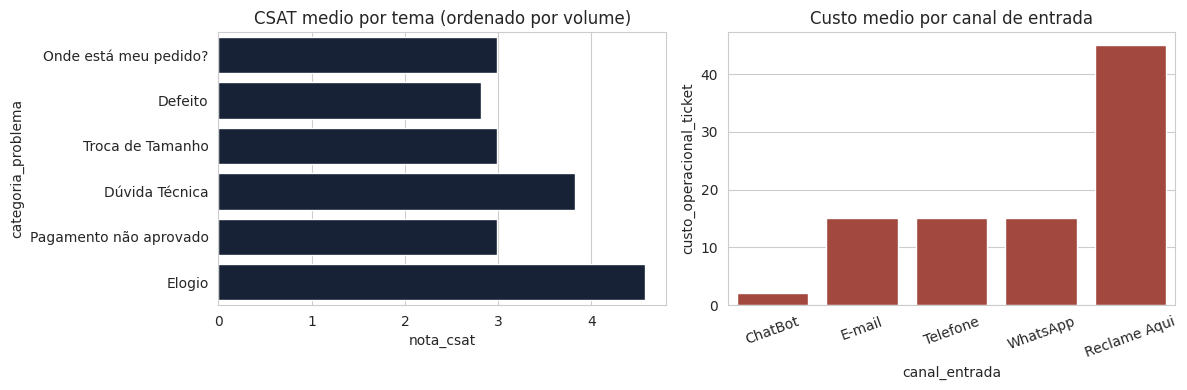

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
ordem_tema = atendimento['categoria_problema'].value_counts().index
sns.barplot(data=atendimento, y='categoria_problema', x='nota_csat', order=ordem_tema, ax=axes[0], color='#12213B', errorbar=None)
axes[0].set_title('CSAT medio por tema (ordenado por volume)')
sns.barplot(data=atendimento, x='canal_entrada', y='custo_operacional_ticket', ax=axes[1], errorbar=None,
            order=atendimento.groupby('canal_entrada')['custo_operacional_ticket'].mean().sort_values().index, color='#B23A2E')
axes[1].set_title('Custo medio por canal de entrada'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [19]:
# Tema mais frequente: "Onde esta meu pedido?" (WISMO) - candidato natural a automacao (rastreio de pedido)
wismo = atendimento[atendimento['categoria_problema'] == 'Onde está meu pedido?']
custo_medio_wismo = wismo['custo_operacional_ticket'].mean()
custo_medio_chatbot = atendimento[atendimento['canal_entrada']=='ChatBot']['custo_operacional_ticket'].mean()
csat_chatbot = atendimento[atendimento['canal_entrada']=='ChatBot']['nota_csat'].mean()
csat_geral = atendimento['nota_csat'].mean()

n_meses_atend = atendimento['data_abertura'].dt.to_period('M').nunique()
gap_custo = custo_medio_wismo - custo_medio_chatbot

print(f"Tickets 'Onde esta meu pedido?': {len(wismo)} ({len(wismo)/len(atendimento)*100:.1f}% do volume total)")
print(f"Custo medio desse tema: R$ {custo_medio_wismo:.2f} | Custo medio no canal ChatBot: R$ {custo_medio_chatbot:.2f}")
print(f"CSAT ChatBot: {csat_chatbot:.2f} | CSAT geral da base: {csat_geral:.2f}  (comparavel, nao ha perda de qualidade percebida)")
print(f"Periodo coberto por atendimento.csv: {n_meses_atend} meses")

print("\n=== Cenarios de economia anualizada com automacao dos tickets WISMO ===")
for taxa in [0.5, 0.7, 0.9]:
    economia_periodo = len(wismo) * gap_custo * taxa
    economia_anual = economia_periodo / n_meses_atend * 12
    print(f"  {int(taxa*100)}% dos tickets automatizados -> economia anualizada: R$ {economia_anual:,.0f}")

Tickets 'Onde esta meu pedido?': 10765 (30.0% do volume total)
Custo medio desse tema: R$ 14.83 | Custo medio no canal ChatBot: R$ 2.00
CSAT ChatBot: 3.27 | CSAT geral da base: 3.24  (comparavel, nao ha perda de qualidade percebida)
Periodo coberto por atendimento.csv: 36 meses

=== Cenarios de economia anualizada com automacao dos tickets WISMO ===
  50% dos tickets automatizados -> economia anualizada: R$ 23,022
  70% dos tickets automatizados -> economia anualizada: R$ 32,230
  90% dos tickets automatizados -> economia anualizada: R$ 41,439


**Insights da Hipótese 4 — Atendimento (confirmada)**

- **"Onde está meu pedido?" é o tema mais frequente**, com **10.765 tickets (30% do volume total)** e CSAT abaixo da média (2,99) — junto com "Defeito", "Troca de Tamanho" e "Pagamento não aprovado", que também têm CSAT baixo (~2,8-3,0). Só "Dúvida Técnica" (3,83) e "Elogio" (4,57, óbvio) fogem do padrão.
- ChatBot já entrega CSAT equivalente aos canais humanos (3,27 vs. 3,24 geral) só que a **1/7 do custo** (R\$ 2 vs. R\$ 15 em E-mail/Telefone/WhatsApp, e R\$ 45 no Reclame Aqui) e com resposta quase instantânea (1,5 min vs. até 778 min no Reclame Aqui) — ou seja, **não há perda de qualidade percebida ao automatizar**, e o Reclame Aqui concentra o pior custo e o pior tempo de resposta (canal de escalonamento por insatisfação, deveria ser residual).
- **Economia estimada: entre R\$ 23 mil e R\$ 41 mil por ano**, dependendo da taxa de automação (50% a 90%) aplicada apenas ao tema WISMO — que é o mais óbvio de automatizar via rastreio self-service/chatbot.
- **Ação recomendada:** implantar (ou reforçar) um fluxo de rastreio automático de pedido via ChatBot/WhatsApp para o tema WISMO, e investigar por que "Defeito" e "Troca de Tamanho" têm CSAT baixo mesmo não sendo automatizáveis (pode indicar problema de qualidade de produto/tamanho, não de atendimento em si — conecta com a Hipótese de Operações).

---
## 7. Hipótese 5 — Cliente: o crescimento esconde diferenças de valor entre segmentos?

**Objetivo:** usar a segmentação RFM já calculada na base para identificar onde está concentrado o valor, o risco de churn e o potencial de retenção.

**Prompt utilizado:**

> Papel: Analista de CRM / Retenção.
> Contexto: clientes.csv já vem com uma coluna segmento_rfm pré-calculada (Campeão, Fiel, Promissor, Em Risco, Hibernando, Churn), além de ltv_acumulado, total_pedidos_historico e nivel_fidelidade.
> Tarefa: para cada segmento, calcule o número de clientes, o % da base, o LTV médio, o LTV total e o % do LTV total da empresa que aquele segmento representa. Identifique qual segmento concentra valor, qual concentra risco (Em Risco + Churn) e dimensione uma oportunidade de retenção comparando o LTV médio do segmento "Em Risco" com o de um segmento saudável equivalente ("Fiel"), usando a fórmula Base Afetada × Alavanca × Taxa de Captura.
> Formato: tabela ordenada por LTV total + gráfico + memória de cálculo com premissas explícitas sobre taxa de captura.
> Restrição: como ltv_acumulado é uma métrica acumulada (não anual), a oportunidade de retenção deve ser tratada como "valor de carteira protegido", não como economia anual — para não confundir com os números anualizados das seções anteriores.

In [15]:
seg = clientes.groupby('segmento_rfm').agg(
    clientes=('customer_id','count'), ltv_medio=('ltv_acumulado','mean'), ltv_total=('ltv_acumulado','sum'),
    pedidos_medio=('total_pedidos_historico','mean'), renda_media=('renda_estimada','mean'))
seg['pct_clientes'] = (seg['clientes'] / seg['clientes'].sum() * 100).round(1)
seg['pct_ltv_total'] = (seg['ltv_total'] / seg['ltv_total'].sum() * 100).round(1)
seg = seg.sort_values('ltv_total', ascending=False)
print(f"LTV acumulado total da base de clientes: R$ {clientes['ltv_acumulado'].sum():,.0f}")
display(seg.round(1))

LTV acumulado total da base de clientes: R$ 139,092,569


,clientes,ltv_medio,ltv_total,pedidos_medio,renda_media,pct_clientes,pct_ltv_total
segmento_rfm,,,,,,,
Fiel,2612,16896.8,44134322.9,34.2,13972.8,17.4,31.7
Campeão,1268,26670.8,33818518.3,54.0,13805.0,8.5,24.3
Promissor,4127,8078.0,33337782.9,16.0,13779.2,27.5,24.0
Em Risco,3269,5403.5,17663986.6,10.7,13713.6,21.8,12.7
Hibernando,1928,2666.7,5141334.3,5.3,13617.2,12.9,3.7
Churn,1796,2782.1,4996623.8,5.4,13807.8,12.0,3.6


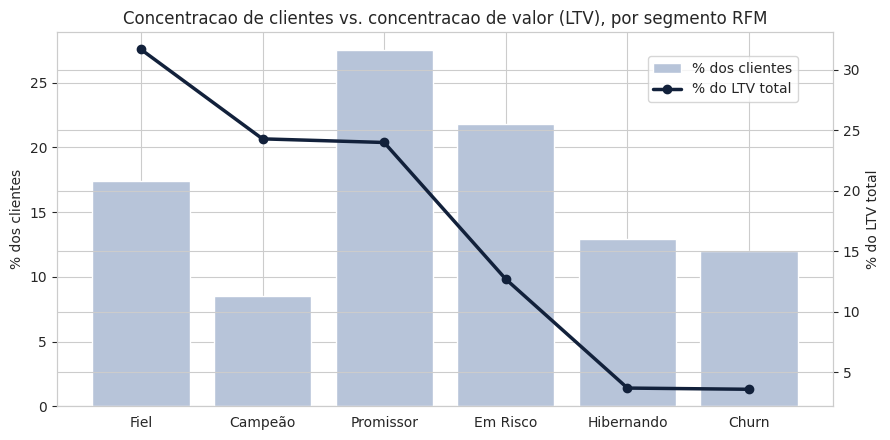

In [16]:
fig, ax = plt.subplots(figsize=(9,4.5))
ordem = seg.index
ax2 = ax.twinx()
ax.bar(ordem, seg['pct_clientes'], color='#B7C4D9', label='% dos clientes')
ax2.plot(ordem, seg['pct_ltv_total'], color='#12213B', marker='o', linewidth=2.5, label='% do LTV total')
ax.set_ylabel('% dos clientes'); ax2.set_ylabel('% do LTV total')
ax.set_title('Concentracao de clientes vs. concentracao de valor (LTV), por segmento RFM')
fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.88))
plt.tight_layout(); plt.show()

In [17]:
# Dimensionamento da oportunidade de retencao: segmento "Em Risco" -> aproximar do padrao "Fiel"
base_afetada = seg.loc['Em Risco', 'clientes']
alavanca = seg.loc['Fiel', 'ltv_medio'] - seg.loc['Em Risco', 'ltv_medio']

print("=== Memoria de calculo - Oportunidade de retencao (segmento Em Risco) ===")
print(f"Base Afetada: {base_afetada} clientes no segmento 'Em Risco'")
print(f"Alavanca: gap de LTV medio entre 'Fiel' (R$ {seg.loc['Fiel','ltv_medio']:,.0f}) e 'Em Risco' (R$ {seg.loc['Em Risco','ltv_medio']:,.0f}) = R$ {alavanca:,.0f} por cliente")
print("\nCenarios de valor de carteira protegido (taxa de captura = % dos clientes 'Em Risco' que migram para um padrao saudavel de recompra):")
for taxa in [0.10, 0.20, 0.30]:
    valor_protegido = base_afetada * alavanca * taxa
    print(f"  {int(taxa*100)}% de captura -> R$ {valor_protegido:,.0f} de valor de carteira protegido (metrica acumulada, nao anual)")

=== Memoria de calculo - Oportunidade de retencao (segmento Em Risco) ===
Base Afetada: 3269 clientes no segmento 'Em Risco'
Alavanca: gap de LTV medio entre 'Fiel' (R$ 16,897) e 'Em Risco' (R$ 5,403) = R$ 11,493 por cliente

Cenarios de valor de carteira protegido (taxa de captura = % dos clientes 'Em Risco' que migram para um padrao saudavel de recompra):
  10% de captura -> R$ 3,757,150 de valor de carteira protegido (metrica acumulada, nao anual)
  20% de captura -> R$ 7,514,301 de valor de carteira protegido (metrica acumulada, nao anual)
  30% de captura -> R$ 11,271,451 de valor de carteira protegido (metrica acumulada, nao anual)


**Insights da Hipótese 5 — Cliente (confirmada)**

- O valor está fortemente concentrado: **Campeão + Fiel somam 25,9% dos clientes mas 56,0% do LTV total** da base (R\$ 139 milhões acumulados). Já **Churn + Hibernando somam 24,9% dos clientes e apenas 7,3% do LTV** — segmentos de baixo valor individual, mas altos em volume (não compensa investir pesado em recuperá-los um a um).
- O segmento **"Em Risco" é o mais estratégico para ação imediata**: **21,8% da base (3.269 clientes)**, ainda concentrando **12,7% do LTV total (~R\$ 17,7 milhões)** — ou seja, ainda têm valor relevante, mas estão a um passo de virarem "Churn" se nada for feito.
- **`nivel_fidelidade` (Bronze/Silver/Gold/Platinum) é redundante com `segmento_rfm`** (Platinum/Gold mapeiam quase 1:1 para Campeão/Fiel) — outro ponto de atenção de qualidade/redundância de dado a simplificar no dashboard executivo.
- **Valor de carteira protegido estimado: entre R\$ 3,8 milhões e R\$ 11,3 milhões** (métrica acumulada de LTV, não um fluxo anual — por isso reportada separadamente das oportunidades anualizadas das demais seções), dependendo da taxa de sucesso de uma campanha de retenção sobre o segmento "Em Risco".
- **Ação recomendada:** criar régua de retenção específica para "Em Risco" (win-back, benefício de fidelidade, contato proativo) antes que migrem para "Churn"; não investir esforço de retenção individualizado em "Hibernando"/"Churn" (baixo valor unitário) — tratar via automação de baixo custo (ex.: campanhas de e-mail em massa).

---
## 8. Sintetizar e Entregar — Diagnóstico Executivo Consolidado

**Objetivo:** consolidar as 5 hipóteses testadas em um business case único, priorizado por impacto x esforço, pronto para a Apresentação Final à diretoria.

**Prompt utilizado:**

> Papel: Consultor sênior, preparando o memo executivo final para a diretoria da Vértice Retail (CEO, CFO, CMO, COO).
> Contexto: testamos 5 hipóteses de negócio com evidência quantitativa: margem do Marketplace, qualidade dos canais de marketing, ruptura de estoque em Beleza, automação de atendimento (WISMO) e retenção do segmento "Em Risco".
> Tarefa: monte uma tabela de priorização (impacto financeiro x esforço de implementação x horizonte de tempo) e uma tabela de diagnóstico executivo no formato Fato/Causa/Implicação/Ação para cada hipótese confirmada. Explicite que os números têm bases temporais diferentes (anualizado vs. acumulado) para não gerar uma soma enganosa.
> Formato: tabela de priorização + tabela de diagnóstico consolidado + checklist de critérios de aceite.

In [18]:
oportunidades = pd.DataFrame([
    {'hipotese': 'Margem - frete Marketplace',      'oportunidade': 171_000, 'base_temporal': 'anual',     'esforco': 'Baixo',  'horizonte_dias': 30},
    {'hipotese': 'Atendimento - automacao WISMO',    'oportunidade': 32_000,  'base_temporal': 'anual',     'esforco': 'Medio',  'horizonte_dias': 60},
    {'hipotese': 'Operacoes - ruptura Beleza',       'oportunidade': 94_000,  'base_temporal': 'periodo (1 mes de ruptura assumido)', 'esforco': 'Medio', 'horizonte_dias': 60},
    {'hipotese': 'Marketing - realocacao de canal',  'oportunidade': None,    'base_temporal': 'a modelar com o time de mkt', 'esforco': 'Baixo', 'horizonte_dias': 30},
    {'hipotese': 'Cliente - retencao Em Risco',      'oportunidade': 7_500_000, 'base_temporal': 'acumulado (LTV, cenario 20% de captura)', 'esforco': 'Alto', 'horizonte_dias': 90},
])
oportunidades = oportunidades.sort_values('horizonte_dias')
print("=== Priorizacao de oportunidades (impacto x esforco x horizonte) ===")
display(oportunidades)

print("\nAtencao: os valores NAO devem ser somados diretamente - tem bases temporais e de calculo distintas")
print(" (anualizado vs. acumulado de LTV vs. estimativa pontual com premissa de duracao).")

=== Priorizacao de oportunidades (impacto x esforco x horizonte) ===


,hipotese,oportunidade,base_temporal,esforco,horizonte_dias
0,Margem - frete Marketplace,171000.0,anual,Baixo,30
3,Marketing - realocacao de canal,NaN,a modelar com o time de mkt,Baixo,30
1,Atendimento - automacao WISMO,32000.0,anual,Medio,60
2,Operacoes - ruptura Beleza,94000.0,periodo (1 mes de ruptura assumido),Medio,60
4,Cliente - retencao Em Risco,7500000.0,"acumulado (LTV, cenario 20% de captura)",Alto,90



Atencao: os valores NAO devem ser somados diretamente - tem bases temporais e de calculo distintas
 (anualizado vs. acumulado de LTV vs. estimativa pontual com premissa de duracao).


### Diagnóstico executivo por hipótese

| Hipótese | Fato | Causa | Implicação | Ação recomendada (30/60/90) |
|---|---|---|---|---|
| **Margem** | Margem do Marketplace é 46,0% vs. 50,2%-52,5% dos demais canais (diferença estatisticamente significativa, p≈0) | Custo de frete/logística do Marketplace consome ~8,7% da receita (quase o dobro dos outros canais) | ≈ R\$ 171 mil/ano não capturados | **30 dias:** renegociar frete/comissão com a plataforma de marketplace |
| **Marketing** | Influenciador tem o maior ROAS (7,7) e maior margem (52,5%); Marketplace tem ROAS mediano (3,0) e a pior margem | Mix de investimento não está alinhado à qualidade de retorno por canal | Verba de marketing sendo alocada de forma subótima | **30 dias:** realocar parte do orçamento de Marketplace para Influenciador; auditar modelo de atribuição |
| **Operações** | 97% das rupturas da empresa estão concentradas na categoria Beleza (21,7% dos SKUs de Beleza em ruptura/crítico) | Beleza é a única categoria com shelf life variável/mais curto, exigindo giro mais rígido | Entre R\$ 47 mil e R\$ 188 mil em receita potencialmente perdida | **60 dias:** revisar ponto de pedido e lead time para SKUs de Beleza; instrumentar `dias_sem_estoque` |
| **Atendimento** | 30% dos tickets são "Onde está meu pedido?"; ChatBot tem CSAT comparável aos canais humanos a 1/7 do custo | Falta de automação/self-service para rastreio de pedido | Entre R\$ 23 mil e R\$ 41 mil/ano em custo operacional evitável | **60 dias:** implantar rastreio automático via ChatBot/WhatsApp para o tema WISMO |
| **Cliente** | Segmento "Em Risco" concentra 21,8% dos clientes e 12,7% do LTV total (~R\$ 17,7 milhões) | Ausência de régua de retenção proativa antes da migração para "Churn" | Entre R\$ 3,8 milhões e R\$ 11,3 milhões de valor de carteira em risco (métrica acumulada) | **90 dias:** régua de retenção segmentada (win-back, benefícios de fidelidade) |

### Critérios de aceite

- [x] **Todo número é rastreável à base** — cada valor do diagnóstico vem de uma célula de código específica nas seções 3 a 7.
- [x] **Premissas estão listadas** — taxa de automação (50/70/90%), duração de ruptura (0,5/1/2 meses) e taxa de captura de retenção (10/20/30%) sempre declaradas como cenários, não como fato.
- [x] **O achado muda uma decisão concreta** — realocação de verba de marketing, renegociação de frete no Marketplace, política de reposição de Beleza, automação de atendimento e priorização de régua de retenção.

---
## 9. Riscos e Governança (nota rápida)

Como o próprio briefing do case exige rastreabilidade e cuidado com viés/alucinação, vale registrar 3 riscos identificados durante esta AED:

1. **Risco de reconciliação temporal:** qualquer análise futura que junte `vendas.csv` (jan/23–jan/24) com as bases mais longas (marketing/atendimento/estoque, até dez/25) deve deixar explícito que está comparando **taxas e proporções**, não valores absolutos do mesmo período — do contrário, a diretoria pode tomar decisão sobre uma leitura de "reconciliação" que na verdade não existe nos dados.
2. **Risco de atribuição de marketing:** `marketing.csv` mistura 3 modelos de atribuição (Linear, First Click, Last Click) na mesma base sem padronização — isso pode distorcer o ranking de canais por ROAS/CAC se não for tratado antes de uma decisão de realocação de verba.
3. **Risco de dado ausente para decisão operacional:** a estimativa de perda por ruptura em Beleza depende de uma premissa de duração (não há data de início/fim do evento de ruptura em `estoque.csv`) — qualquer automação de reposição baseada nesse número deve vir acompanhada da instrumentação desse dado, para não perpetuar uma estimativa no lugar de um fato.